# Task 3 – Feature Engineering
**BCG X | PowerCo Churn Prediction**

**Goal:** Transform raw client and price data into meaningful features that will help predict which customers are likely to churn.

---
1. Import packages
2. Load data
3. Feature engineering
   - 3a. Off-peak price diff Dec vs Jan (colleague's starter code)
   - 3b. All-period price diffs
   - 3c. Price volatility per customer
   - 3d. Date-based features
   - 3e. Consumption ratio features
   - 3f. Margin features
   - 3g. Encode categoricals
4. Visualise new features vs churn
5. Correlation heatmap
6. Save engineered dataset

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

print('Packages loaded.')

Packages loaded.


## 2. Load data

In [2]:
df = pd.read_csv('./clean_data_after_eda.csv')

for col in ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

price_df = pd.read_csv('./price_data.csv')
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

print(f'Client data : {df.shape}')
print(f'Price data  : {price_df.shape}')
df.head(3)

Client data : (14606, 26)
Price data  : (193002, 8)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


## 3. Feature Engineering

### 3a. Off-peak price difference: December vs January
*(Starter code from your colleague – recreated exactly)*

**Why?** If a customer's off-peak price rose significantly from January to December, they experienced price pressure all year. This is a direct proxy for **price sensitivity** – the core hypothesis of the project.

In [3]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean',
    'price_off_peak_fix': 'mean'
}).reset_index()

# Get January and December prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(
    dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}),
    jan_prices.drop(columns='price_date'),
    on='id'
)
diff['offpeak_diff_dec_jan_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_jan_power']  = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power']]

df = df.merge(diff, on='id', how='left')
print('✓ Off-peak Dec vs Jan features added')
diff.head()

✓ Off-peak Dec vs Jan features added


,id,offpeak_diff_dec_jan_energy,offpeak_diff_dec_jan_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


### 3b. Extend the idea – peak & mid-peak price diffs (Dec vs Jan)

**Why?** The colleague's code only looked at off-peak prices. Peak and mid-peak pricing changes may also drive churn, especially for high-consumption business customers.

In [4]:
monthly_all = price_df.groupby(['id', 'price_date']).agg({
    'price_peak_var':     'mean',
    'price_mid_peak_var': 'mean',
    'price_peak_fix':     'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

jan_all = monthly_all.groupby('id').first().reset_index()
dec_all = monthly_all.groupby('id').last().reset_index()

diff2 = pd.merge(
    dec_all.rename(columns={
        'price_peak_var':     'price_peak_var_dec',
        'price_mid_peak_var': 'price_mid_peak_var_dec',
        'price_peak_fix':     'price_peak_fix_dec',
        'price_mid_peak_fix': 'price_mid_peak_fix_dec'
    }),
    jan_all.drop(columns='price_date'),
    on='id'
)

diff2['peak_diff_dec_jan_energy']     = diff2['price_peak_var_dec']     - diff2['price_peak_var']
diff2['mid_peak_diff_dec_jan_energy'] = diff2['price_mid_peak_var_dec'] - diff2['price_mid_peak_var']
diff2['peak_diff_dec_jan_power']      = diff2['price_peak_fix_dec']     - diff2['price_peak_fix']
diff2 = diff2[['id', 'peak_diff_dec_jan_energy', 'mid_peak_diff_dec_jan_energy', 'peak_diff_dec_jan_power']]

df = df.merge(diff2, on='id', how='left')
print('✓ Peak & mid-peak Dec vs Jan features added')
diff2.head()

✓ Peak & mid-peak Dec vs Jan features added


,id,peak_diff_dec_jan_energy,mid_peak_diff_dec_jan_energy,peak_diff_dec_jan_power
0,0002203ffbb812588b632b9e628cc38d,-0.002302,0.003487,0.097749
1,0004351ebdd665e6ee664792efc4fd13,0.000000,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.000000,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,-0.005120,0.000763,0.097749
4,00114d74e963e47177db89bc70108537,0.000000,0.000000,0.000000


### 3c. Price volatility per customer across 2015

**Why?** A customer whose price changed a lot month-to-month experienced instability. High volatility may make them more likely to shop around and churn.

In [5]:
price_vol = price_df.groupby('id').agg(
    std_offpeak_var  = ('price_off_peak_var', 'std'),
    std_peak_var     = ('price_peak_var',     'std'),
    mean_offpeak_var = ('price_off_peak_var', 'mean'),
    mean_peak_var    = ('price_peak_var',     'mean')
).reset_index().fillna(0)

df = df.merge(price_vol, on='id', how='left')
print('✓ Price volatility features added')
price_vol.describe().round(4)

✓ Price volatility features added


,std_offpeak_var,std_peak_var,mean_offpeak_var,mean_peak_var
count,16096.0000,16096.0000,16096.0000,16096.0000
mean,0.0042,0.0026,0.1410,0.0546
std,0.0052,0.0062,0.0242,0.0495
min,0.0000,0.0000,0.0000,0.0000
25%,0.0022,0.0000,0.1241,0.0000
50%,0.0032,0.0014,0.1473,0.0859
75%,0.0043,0.0021,0.1502,0.1023
max,0.0690,0.0696,0.2788,0.1963


### 3d. Date-based features

**Why?** Customers near contract end may be more likely to switch. Long gaps between product modifications could indicate neglected accounts. Tenure directly affects loyalty.

In [6]:
ref_date = pd.Timestamp('2016-01-01')  # reference point (just after data collection)

df['contract_duration_days'] = (df['date_end']      - df['date_activ']).dt.days
df['days_to_renewal']        = (df['date_renewal']  - ref_date).dt.days
df['months_since_modif']     = ((ref_date - df['date_modif_prod']).dt.days / 30).round()

print('✓ Date-based features added')
df[['contract_duration_days', 'days_to_renewal', 'months_since_modif']].describe().round(1)

✓ Date-based features added


,contract_duration_days,days_to_renewal,months_since_modif
count,14606.0,14606.0,14606.0
mean,2007.5,-163.7,36.4
std,604.9,118.4,30.8
min,731.0,-919.0,-1.0
25%,1461.0,-259.0,7.0
50%,1828.5,-158.0,31.0
75%,2353.0,-64.0,66.0
max,4795.0,27.0,154.0


### 3e. Consumption ratio features

**Why?** Raw consumption values are skewed. Ratios tell a more nuanced story – e.g. a customer whose last month usage is much lower than their 12-month average may be disengaging.

In [7]:
df['cons_last_vs_12m']   = df['cons_last_month'] / (df['cons_12m'] + 1)   # recent vs annual
df['forecast_vs_actual'] = df['forecast_cons_12m'] / (df['cons_12m'] + 1) # forecasted vs actual
df['gas_to_elec_ratio']  = df['cons_gas_12m']  / (df['cons_12m'] + 1)    # gas vs electricity usage

print('✓ Consumption ratio features added')
df[['cons_last_vs_12m', 'forecast_vs_actual', 'gas_to_elec_ratio']].describe().round(3)

✓ Consumption ratio features added


,cons_last_vs_12m,forecast_vs_actual,gas_to_elec_ratio
count,14606.000,14606.000,14606.000
mean,0.077,1.691,43.661
std,0.085,53.725,2365.834
min,0.000,0.000,0.000
25%,0.000,0.043,0.000
50%,0.072,0.102,0.000
75%,0.112,0.147,0.000
max,1.260,3534.240,193458.000


### 3f. Margin features

**Why?** The gap between gross and net margin per customer indicates cost burden. A low-margin customer may receive less retention effort, increasing churn risk.

In [8]:
df['gross_net_margin_diff']  = df['margin_gross_pow_ele'] - df['margin_net_pow_ele']
df['net_margin_per_product'] = df['net_margin'] / df['nb_prod_act']

print('✓ Margin features added')
df[['gross_net_margin_diff', 'net_margin_per_product']].describe().round(2)

✓ Margin features added


,gross_net_margin_diff,net_margin_per_product
count,14606.00,14606.00
mean,0.00,161.51
std,0.27,225.15
min,0.00,0.00
25%,0.00,41.74
50%,0.00,95.07
75%,0.00,205.77
max,31.34,10203.50


### 3g. Encode categorical columns

**Why?** ML models need numbers. `has_gas` is a boolean string; `channel_sales` and `origin_up` are hashed categories – we one-hot encode them.

In [9]:
# Binary encode has_gas
df['has_gas_enc'] = (df['has_gas'] == 't').astype(int)

# One-hot encode channel_sales and origin_up
df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], drop_first=True)

print('✓ Categorical features encoded')
print(f'Dataset shape after encoding: {df.shape}')

✓ Categorical features encoded


Dataset shape after encoding: (14606, 54)


### Feature summary

In [10]:
original_cols = [
    'id','has_gas','cons_12m','cons_gas_12m','cons_last_month','date_activ',
    'date_end','date_modif_prod','date_renewal','forecast_cons_12m','forecast_cons_year',
    'forecast_discount_energy','forecast_meter_rent_12m','forecast_price_energy_off_peak',
    'forecast_price_energy_peak','forecast_price_pow_off_peak','imp_cons',
    'margin_gross_pow_ele','margin_net_pow_ele','nb_prod_act','net_margin',
    'num_years_antig','pow_max','churn'
]
new_features = [c for c in df.columns if c not in original_cols]
print(f'Total new features created: {len(new_features)}')
for f in new_features:
    print(f'  • {f}')

Total new features created: 30
  • offpeak_diff_dec_jan_energy
  • offpeak_diff_dec_jan_power
  • peak_diff_dec_jan_energy
  • mid_peak_diff_dec_jan_energy
  • peak_diff_dec_jan_power
  • std_offpeak_var
  • std_peak_var
  • mean_offpeak_var
  • mean_peak_var
  • contract_duration_days
  • days_to_renewal
  • months_since_modif
  • cons_last_vs_12m
  • forecast_vs_actual
  • gas_to_elec_ratio
  • gross_net_margin_diff
  • net_margin_per_product
  • has_gas_enc
  • channel_sales_epumfxlbckeskwekxbiuasklxalciiuu
  • channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci
  • channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa
  • channel_sales_foosdfpfkusacimwkcsosbicdxkicaua
  • channel_sales_lmkebamcaaclubfxadlmueccxoimlema
  • channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds
  • channel_sales_usilxuppasemubllopkaafesmlibmsdf
  • origin_up_ewxeelcelemmiwuafmddpobolfuxioce
  • origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws
  • origin_up_ldkssxwpmemidmecebumciepifcamkci
  • origin_up_lxidpiddsbxsbosboudacoc

## 4. Visualise new features vs churn

This is what the course is asking you to do: **plot each engineered feature split by churn vs retention** to see which features actually separate the two groups visually.

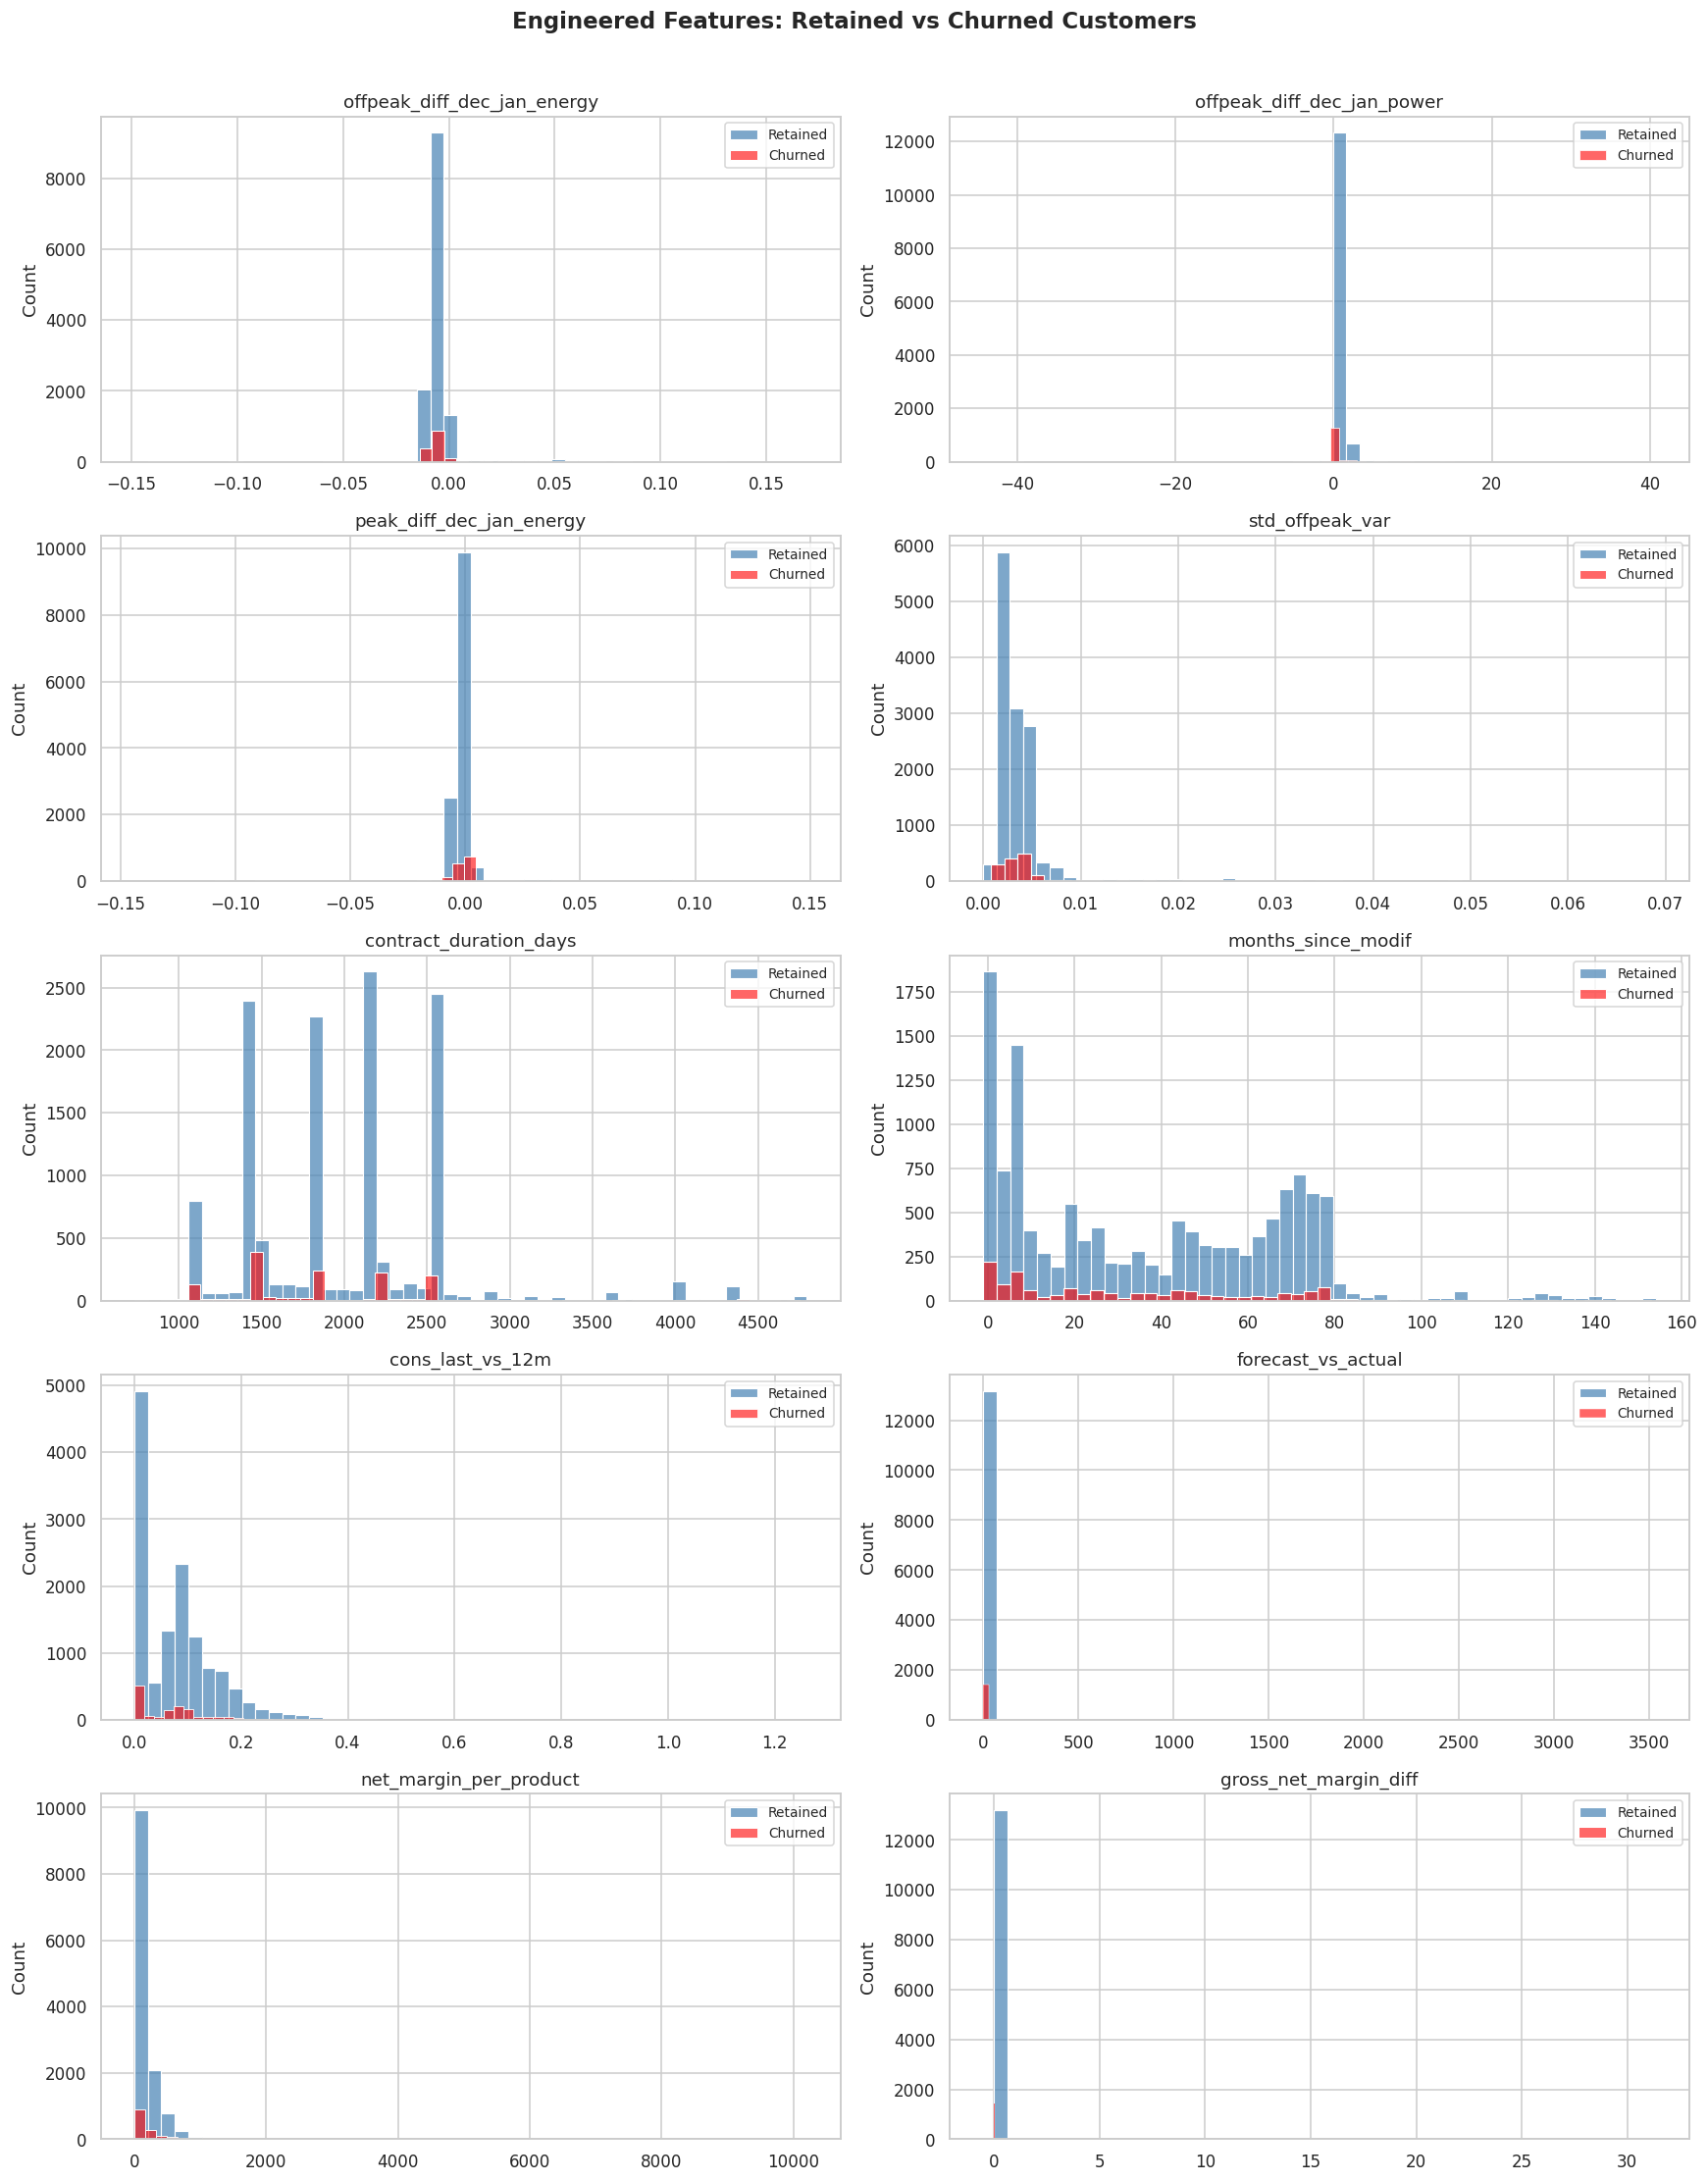

In [11]:
# The incomplete code from the notebook – completed:
# sns.histplot(df[df['target'] == 0][''])  ← target = churn, '' = column name

# Key engineered features to visualise
features_to_plot = [
    'offpeak_diff_dec_jan_energy',
    'offpeak_diff_dec_jan_power',
    'peak_diff_dec_jan_energy',
    'std_offpeak_var',
    'contract_duration_days',
    'months_since_modif',
    'cons_last_vs_12m',
    'forecast_vs_actual',
    'net_margin_per_product',
    'gross_net_margin_diff'
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
fig.suptitle('Engineered Features: Retained vs Churned Customers', fontsize=15, fontweight='bold', y=1.01)

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.histplot(df[df['churn'] == 0][feature], bins=50, ax=ax,
                 color='steelblue', label='Retained', alpha=0.7)
    sns.histplot(df[df['churn'] == 1][feature], bins=50, ax=ax,
                 color='red', label='Churned', alpha=0.6)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

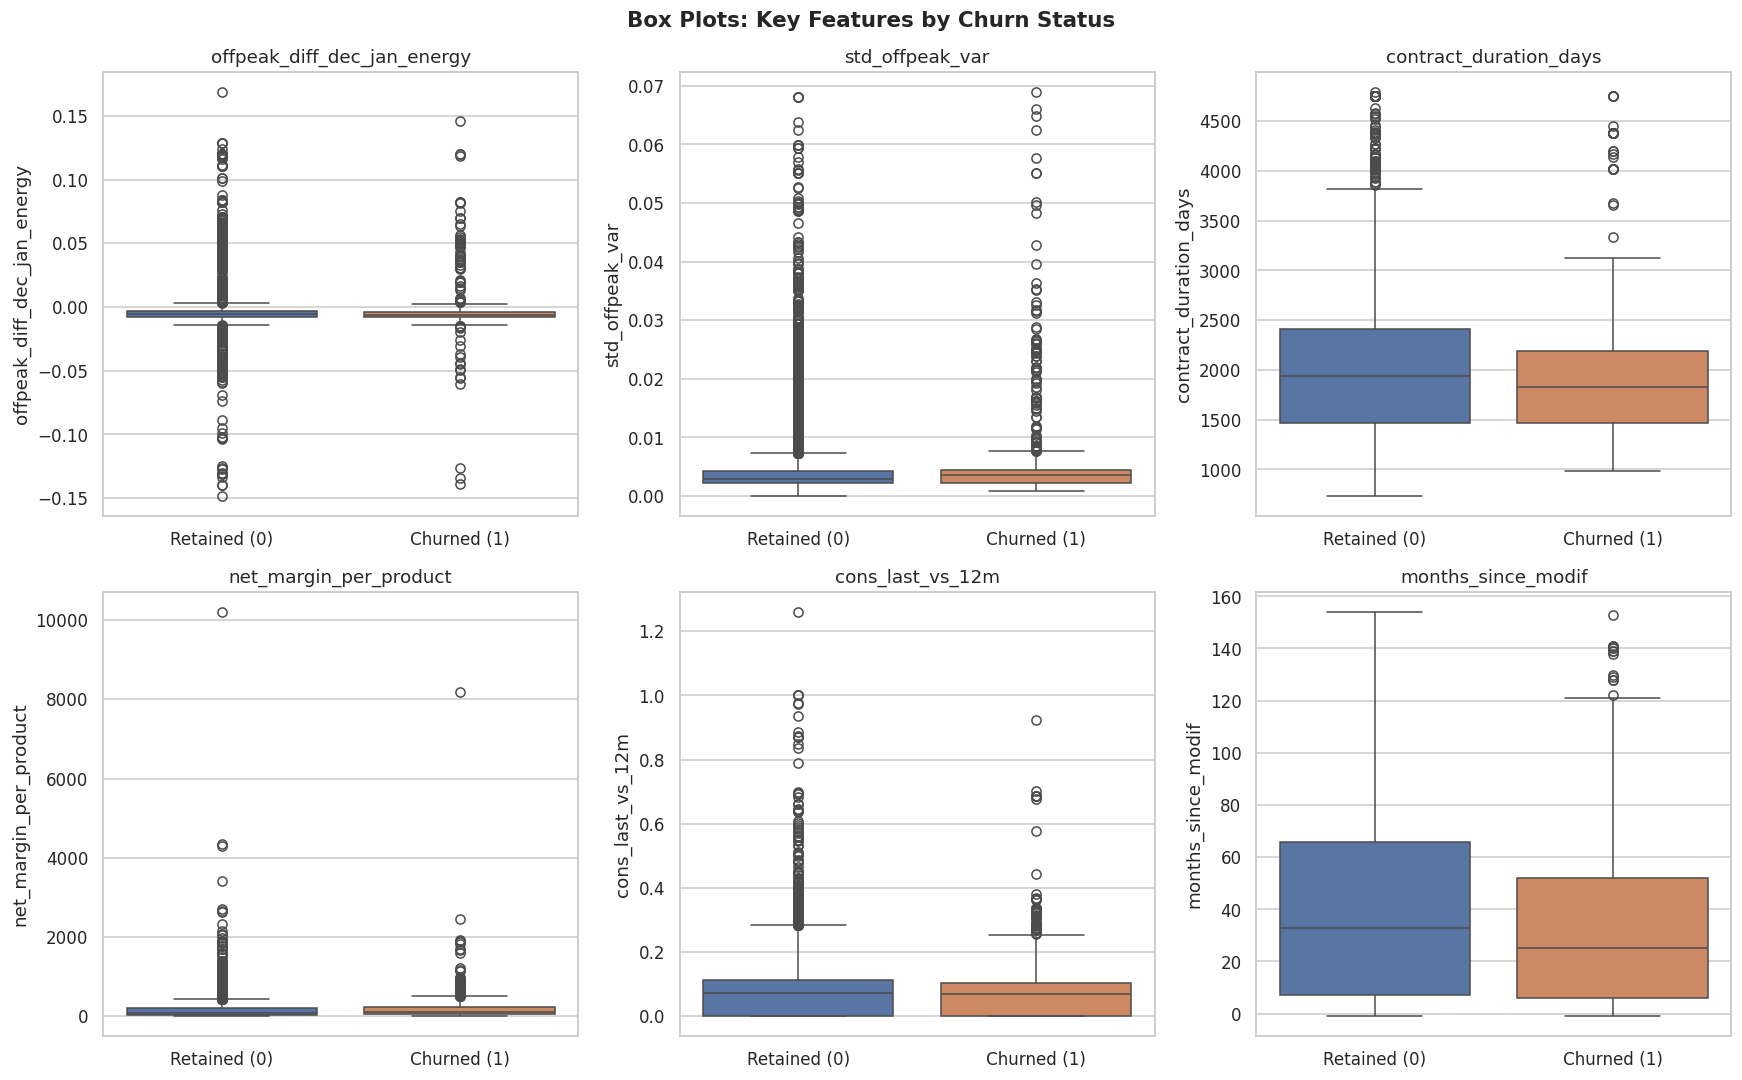

In [12]:
# Box plots for cleaner comparison on key features
box_features = [
    'offpeak_diff_dec_jan_energy', 'std_offpeak_var',
    'contract_duration_days',      'net_margin_per_product',
    'cons_last_vs_12m',            'months_since_modif'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Box Plots: Key Features by Churn Status', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), box_features):
    sns.boxplot(
        data=df, x='churn', y=feature, ax=ax,
        palette=['#4C72B0', '#DD8452']
    )
    ax.set_xticklabels(['Retained (0)', 'Churned (1)'])
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 5. Correlation heatmap

Check how the new features relate to each other and to the churn target.

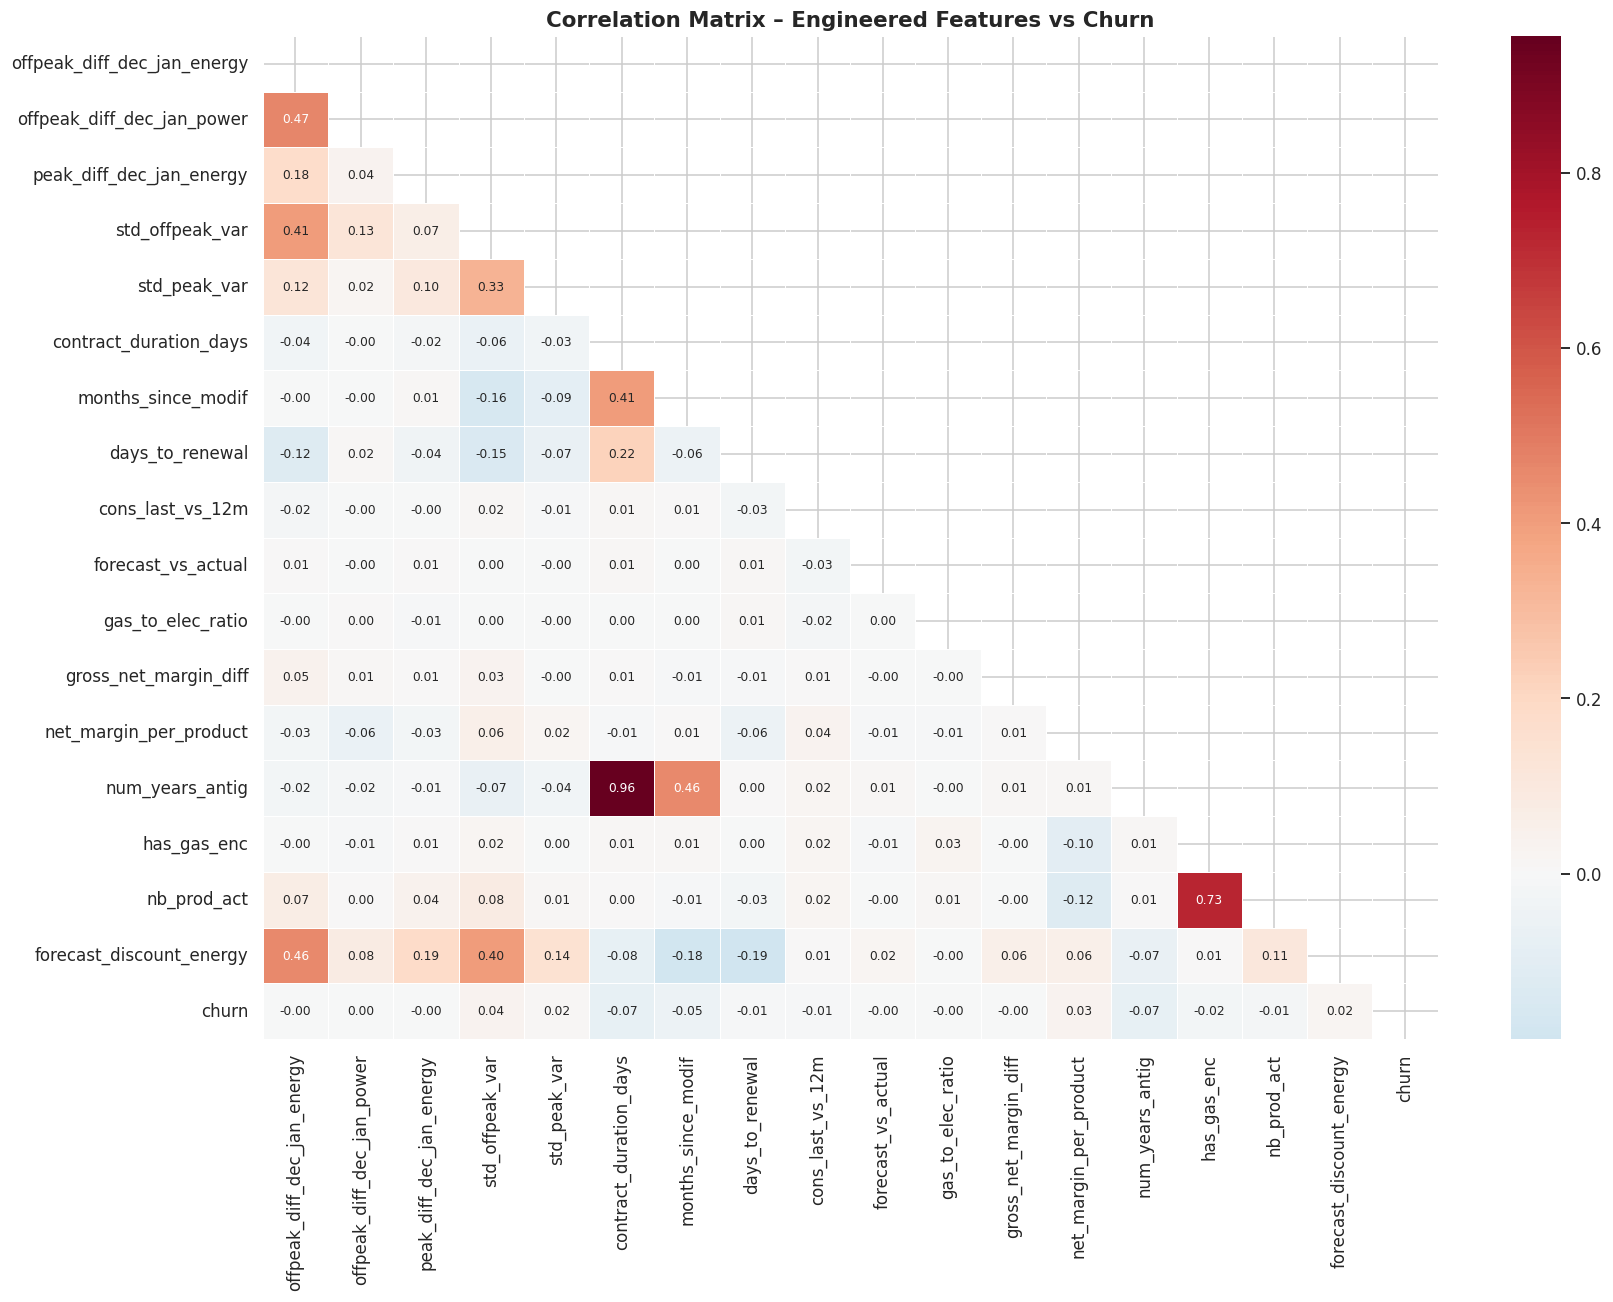

In [13]:
numeric_features = [
    'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power',
    'peak_diff_dec_jan_energy',    'std_offpeak_var', 'std_peak_var',
    'contract_duration_days',      'months_since_modif', 'days_to_renewal',
    'cons_last_vs_12m',            'forecast_vs_actual', 'gas_to_elec_ratio',
    'gross_net_margin_diff',       'net_margin_per_product',
    'num_years_antig',             'has_gas_enc', 'nb_prod_act',
    'forecast_discount_energy',    'churn'
]

corr = df[numeric_features].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix – Engineered Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Which features correlate most with churn?
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
print('Features ranked by absolute correlation with churn:')
print(churn_corr.round(4).to_string())

Features ranked by absolute correlation with churn:
num_years_antig               -0.0741
contract_duration_days        -0.0739
months_since_modif            -0.0521
std_offpeak_var                0.0374
net_margin_per_product         0.0345
has_gas_enc                   -0.0243
forecast_discount_energy       0.0170
std_peak_var                   0.0162
nb_prod_act                   -0.0149
cons_last_vs_12m              -0.0091
days_to_renewal               -0.0062
peak_diff_dec_jan_energy      -0.0040
gross_net_margin_diff         -0.0032
offpeak_diff_dec_jan_power     0.0027
forecast_vs_actual            -0.0022
offpeak_diff_dec_jan_energy   -0.0011
gas_to_elec_ratio             -0.0006


## 6. Save the engineered dataset

In [15]:
# Drop raw date columns (not usable by ML directly) and raw categoricals already encoded
drop_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'has_gas', 'id']
df_model = df.drop(columns=drop_cols, errors='ignore')

df_model.to_csv('./engineered_data.csv', index=False)
print(f'Saved engineered_data.csv  →  shape: {df_model.shape}')
print(f'Columns: {df_model.columns.tolist()}')

Saved engineered_data.csv  →  shape: (14606, 48)
Columns: ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig', 'pow_max', 'churn', 'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power', 'peak_diff_dec_jan_energy', 'mid_peak_diff_dec_jan_energy', 'peak_diff_dec_jan_power', 'std_offpeak_var', 'std_peak_var', 'mean_offpeak_var', 'mean_peak_var', 'contract_duration_days', 'days_to_renewal', 'months_since_modif', 'cons_last_vs_12m', 'forecast_vs_actual', 'gas_to_elec_ratio', 'gross_net_margin_diff', 'net_margin_per_product', 'has_gas_enc', 'channel_sales_epumfxlbckeskwekxbiuasklxalciiuu', 'channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci', 'channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa', 'channel_

---
## What the course is asking you to do – Summary

| Step | What to do | Why |
|------|-----------|-----|
| **Reproduce colleague's code** | Calculate Dec vs Jan off-peak price difference | Establishes the price sensitivity feature as a baseline |
| **Extend the idea** | Do the same for peak & mid-peak periods | More complete picture of price changes across tariff bands |
| **Get creative** | Build new features from dates, consumption ratios, margins, price volatility | The course wants you to think like a Data Scientist – raw data is rarely model-ready |
| **Visualise** | Plot each feature split by churn vs retained | Validate that features actually separate the two groups before wasting model training time |
| **Correlation check** | Heatmap of features vs churn | Spot multicollinearity and find the most predictive candidates |
| **Save output** | Export `engineered_data.csv` | This feeds into Task 4 – model training |

**The core business question throughout:** *Is price sensitivity the main driver of churn?*  
Your features are designed to test that hypothesis numerically.